# s02a — Distancia euclidiana y distancia de red a estaciones SITVA
## CM0866 · Análisis Exploratorio de Datos Espaciales · EAFIT 2026

---

### Objetivo

Calcular, para cada manzana de Medellín, dos medidas de accesibilidad a la estación SITVA más cercana:

1. **Distancia euclidiana** — línea recta entre el centroide de la manzana y la estación más cercana
2. **Distancia de red peatonal** — recorrido mínimo sobre la red de caminos disponible (shortest path, algoritmo de Dijkstra)

Al final comparamos las dos medidas y calculamos el **ratio red/euclidiana** — un índice de tortuosidad que revela dónde la topografía y la trama urbana penalizan más la accesibilidad real.

### Archivos de entrada
```
amva_sitva_nodes_32618.shp     → estaciones SITVA (puntos, EPSG:32618)
manzanas_medellin_dane_2018_32618.shp  → manzanas (polígonos, EPSG:32618)
manzanas_centroids_32618.shp   → centroides de manzanas (puntos, EPSG:32618)
MDE_edges_walk_32618.shp       → red peatonal — aristas (líneas, EPSG:32618)
```

### Concepto clave
```
d_euclidiana(i,j) = √((xᵢ−xⱼ)² + (yᵢ−yⱼ)²)          → O(n) sobre STR-tree
d_red(i,j)        = min Σ_{e∈P} w(e)  s.t. P ∈ G       → Dijkstra O((V+E)log V)
ratio(i)          = d_red(i, j*) / d_euclidiana(i, j*)  → ≥ 1 siempre
```
donde j* es la estación más cercana en línea recta.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Configuración
# Modifica solo esta celda si cambias rutas o parámetros
# ─────────────────────────────────────────────────────────────────────────────

CRS               = 32618          # UTM Zona 18N / WGS84 — metros
VELOCIDAD_PEAT    = 1.2            # m/s — velocidad peatonal media en ladera
MUESTRA_RED       = 500            # manzanas para el cálculo de red (puede tardar)

# Rutas de archivos — ajustar según estructura de carpetas
RUTA_SITVA        = "zip://../datos/morfologia/amva_sitva.zip!""amva_sitva_nodes.shp"
RUTA_MANZANAS     = '../datos/morfologia/manzanas_medellin_dane_2018.zip'
# RUTA_CENTROIDES   = '../datos/morfologia/manzanas_centroids.zip'
RUTA_RED_PEAT     = "zip://../datos/morfologia/Street_Network.zip!""MDE_edges_walk_32618.shp"
RUTA_OUTPUTS      = 'outputs/'


import os
os.makedirs(RUTA_OUTPUTS, exist_ok=True)
print('✓ Configuración lista')
print(f'  CRS de análisis:       EPSG:{CRS}')
print(f'  Velocidad peatonal:    {VELOCIDAD_PEAT} m/s ({VELOCIDAD_PEAT*3.6:.1f} km/h)')
print(f'  Muestra para red:      {MUESTRA_RED} manzanas')

✓ Configuración lista
  CRS de análisis:       EPSG:32618
  Velocidad peatonal:    1.2 m/s (4.3 km/h)
  Muestra para red:      500 manzanas


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Importar librerías
# ─────────────────────────────────────────────────────────────────────────────

import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

print(f'GeoPandas:   {gpd.__version__}')
print(f'NetworkX:    {nx.__version__}')
print(f'NumPy:       {np.__version__}')
print('✓ Librerías importadas')

GeoPandas:   1.0.1
NetworkX:    3.6.1
NumPy:       2.1.1
✓ Librerías importadas


---
## Parte 1 — Cargar y verificar los datos

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Cargar capas
# ─────────────────────────────────────────────────────────────────────────────

def verificar_capa(gdf, nombre):
    """Verifica CRS, conteo y geometrías de una capa."""
    epsg = gdf.crs.to_epsg() if gdf.crs else 'sin CRS'
    geom_tipo = gdf.geometry.geom_type.value_counts().index[0]
    invalidas = (~gdf.geometry.is_valid).sum()
    print(f'  {nombre}')
    print(f'    Entidades: {len(gdf):>8,}  |  CRS: EPSG:{epsg}  |  Geometría: {geom_tipo}  |  Inválidas: {invalidas}')
    if epsg != CRS:
        print(f'    ⚠  CRS incorrecto — reproyectando a EPSG:{CRS}...')
        gdf = gdf.to_crs(epsg=CRS)
        print(f'    ✓  Reproyectado')
    return gdf

print('Cargando capas...')
print()

sitva      = gpd.read_file(RUTA_SITVA)
manzanas   = gpd.read_file(RUTA_MANZANAS)
# centroides = gpd.read_file(RUTA_CENTROIDES)
red_peat   = gpd.read_file(RUTA_RED_PEAT)

# calcular centroides a partir de manzanas
centroides = manzanas.copy()
centroides['geometry'] = centroides.centroid

sitva      = verificar_capa(sitva,      'Estaciones SITVA')
manzanas   = verificar_capa(manzanas,   'Manzanas DANE')
centroides = verificar_capa(centroides, 'Centroides manzanas')
red_peat   = verificar_capa(red_peat,   'Red peatonal (aristas)')

print()
print('✓ Todas las capas cargadas en EPSG:', CRS)

Cargando capas...

  Estaciones SITVA
    Entidades:       75  |  CRS: EPSG:4326  |  Geometría: Point  |  Inválidas: 0
    ⚠  CRS incorrecto — reproyectando a EPSG:32618...
    ✓  Reproyectado
  Manzanas DANE
    Entidades:   22,008  |  CRS: EPSG:4326  |  Geometría: Polygon  |  Inválidas: 0
    ⚠  CRS incorrecto — reproyectando a EPSG:32618...
    ✓  Reproyectado
  Centroides manzanas
    Entidades:   22,008  |  CRS: EPSG:4326  |  Geometría: Point  |  Inválidas: 0
    ⚠  CRS incorrecto — reproyectando a EPSG:32618...
    ✓  Reproyectado
  Red peatonal (aristas)
    Entidades:  294,038  |  CRS: EPSG:32618  |  Geometría: LineString  |  Inválidas: 0

✓ Todas las capas cargadas en EPSG: 32618


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Explorar los datos
# ─────────────────────────────────────────────────────────────────────────────

print('─── Estaciones SITVA ───')
print(f'Total de estaciones: {len(sitva)}')
print(f'Columnas: {list(sitva.columns)}')
print()

# Ver si hay campo de nombre o tipo de estación
cols_nombre = [c for c in sitva.columns if any(k in c.lower() for k in ['name','nombre','tipo','type','sistema','linea'])]
if cols_nombre:
    for col in cols_nombre[:3]:
        print(f'  {col}: {sitva[col].value_counts().head(5).to_dict()}')
print()

print('─── Centroides de manzanas ───')
print(f'Total: {len(centroides):,}')
print(f'Columnas: {list(centroides.columns[:8])}')
print()

print('─── Red peatonal ───')
print(f'Total aristas: {len(red_peat):,}')
longitud_total = red_peat.geometry.length.sum() / 1000
print(f'Longitud total: {longitud_total:,.1f} km')
print(f'Longitud media de arista: {red_peat.geometry.length.mean():.1f} m')

─── Estaciones SITVA ───
Total de estaciones: 75
Columnas: ['num', 'nb', 'Name', 'System', 'ID_station', 'idstation', 'x_cood', 'y_coord', 'geometry']

  Name: {'Palos_Verdes': 1, 'Gardel': 1, 'Unknown': 1, 'Las_Esmeraldas': 1, 'Berlin': 1}

─── Centroides de manzanas ───
Total: 22,008
Columnas: ['COD_DANE_A', 'DPTO_CCDGO', 'MPIO_CCDGO', 'MPIO_CDPMP', 'CLAS_CCDGO', 'SETR_CCDGO', 'SETR_CCNCT', 'SECR_CCDGO']

─── Red peatonal ───
Total aristas: 294,038
Longitud total: 30,611.1 km
Longitud media de arista: 104.1 m


---
## Parte 2 — Distancia euclidiana

Para cada centroide de manzana calculamos la distancia en línea recta a **todas** las estaciones SITVA y nos quedamos con la mínima.

**Fórmula:**
```
d_euclidiana(i, j) = √((xᵢ−xⱼ)² + (yᵢ−yⱼ)²)
d_min_euclidiana(i) = min_j d_euclidiana(i, j)
```

GeoPandas usa un STR-tree internamente para acelerar la búsqueda — O(log n) en lugar de O(n·m).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Distancia euclidiana: centroide → estación más cercana
# ─────────────────────────────────────────────────────────────────────────────

print('Calculando distancia euclidiana...')
print(f'  {len(centroides):,} centroides × {len(sitva)} estaciones')
print()

# sjoin_nearest: para cada centroide encuentra la estación más cercana
# Usa STR-tree internamente — eficiente incluso con 200k manzanas
nearest_euclidiana = gpd.sjoin_nearest(
    centroides,
    sitva,
    how='left',
    distance_col='dist_euclidiana_m'
)

# Si hay duplicados (manzanas equidistantes a dos estaciones), quedarse con la primera
nearest_euclidiana = nearest_euclidiana.loc[
    ~nearest_euclidiana.index.duplicated(keep='first')
]

print(f'✓ Distancia euclidiana calculada')
print(f'  Mínima:  {nearest_euclidiana.dist_euclidiana_m.min():.0f} m')
print(f'  Media:   {nearest_euclidiana.dist_euclidiana_m.mean():.0f} m')
print(f'  Mediana: {nearest_euclidiana.dist_euclidiana_m.median():.0f} m')
print(f'  Máxima:  {nearest_euclidiana.dist_euclidiana_m.max():.0f} m')
print()

# ¿Cuántas manzanas están a menos de 500m de una estación?
dentro_500m = (nearest_euclidiana.dist_euclidiana_m <= 500).sum()
pct_500m = dentro_500m / len(nearest_euclidiana) * 100
print(f'  Manzanas a ≤ 500m euclidiana: {dentro_500m:,} ({pct_500m:.1f}%)')
print(f'  Manzanas a > 500m euclidiana: {len(nearest_euclidiana)-dentro_500m:,} ({100-pct_500m:.1f}%)')

Calculando distancia euclidiana...
  22,008 centroides × 75 estaciones

✓ Distancia euclidiana calculada
  Mínima:  1 m
  Media:   1885 m
  Mediana: 1042 m
  Máxima:  32195 m

  Manzanas a ≤ 500m euclidiana: 4,790 (21.8%)
  Manzanas a > 500m euclidiana: 17,218 (78.2%)


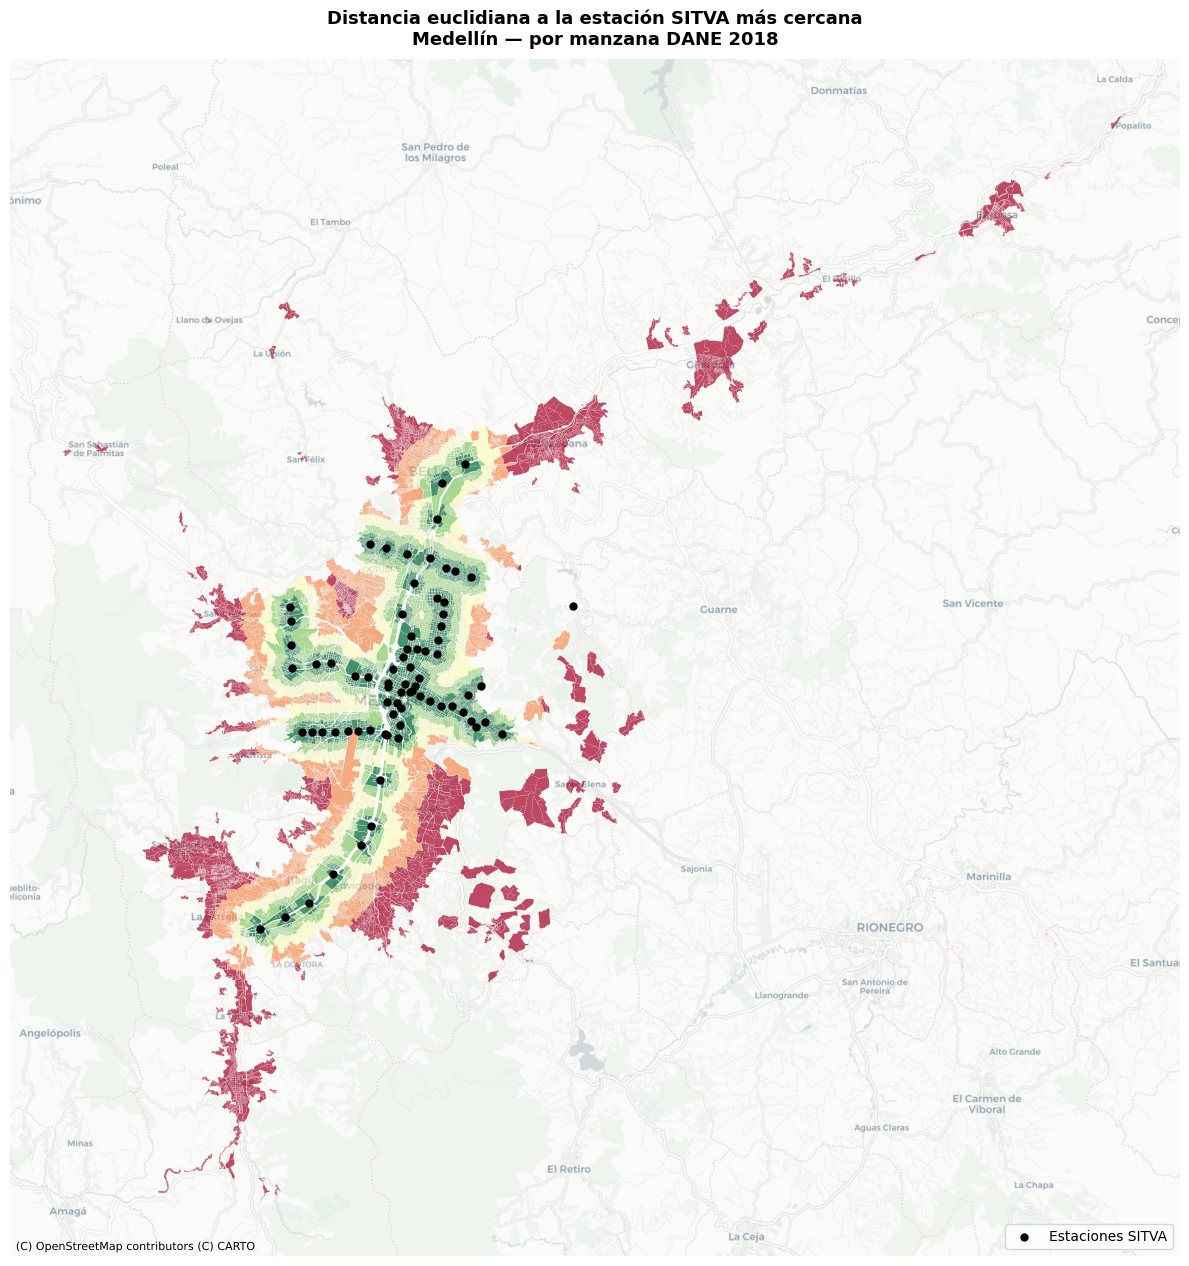

✓ Mapa guardado: outputs/s02a_distancia_euclidiana.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Mapa de distancia euclidiana
# ─────────────────────────────────────────────────────────────────────────────

# Unir distancias a las manzanas para el mapa
manzanas_plot = manzanas.copy()
manzanas_plot = manzanas_plot.merge(
    nearest_euclidiana[['dist_euclidiana_m']],
    left_index=True, right_index=True, how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

manzanas_plot.to_crs(epsg=3857).plot(
    column='dist_euclidiana_m',
    cmap='RdYlGn_r',          # rojo = lejos, verde = cerca
    scheme='quantiles', k=5,
    legend=True,
    legend_kwds={
        'title': 'Distancia euclidiana\na estación SITVA (m)',
        'fmt': '{:.0f}'
    },
    alpha=0.7,
    linewidth=0.05,
    edgecolor='white',
    ax=ax
)

# Superponer estaciones SITVA
sitva.to_crs(epsg=3857).plot(
    ax=ax, color='black', markersize=25, zorder=5,
    label='Estaciones SITVA'
)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
except Exception:
    pass

ax.set_title('Distancia euclidiana a la estación SITVA más cercana\nMedellín — por manzana DANE 2018', 
             fontsize=13, fontweight='bold', pad=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_axis_off()

plt.tight_layout()
ruta_mapa = f'{RUTA_OUTPUTS}s02a_distancia_euclidiana.png'
plt.savefig(ruta_mapa, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Mapa guardado: {ruta_mapa}')

---
## Parte 3 — Construir el grafo de red peatonal

Para calcular la distancia de red necesitamos representar la red peatonal como un **grafo** G = (V, E, w), donde:
- V = nodos (intersecciones y extremos de segmentos)
- E = aristas (segmentos peatonales)
- w = peso de cada arista (longitud en metros)

Construimos el grafo desde las aristas del shapefile usando los endpoints de cada segmento como nodos.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Construir el grafo desde las aristas peatonales
# ─────────────────────────────────────────────────────────────────────────────

from shapely.geometry import Point

print('Construyendo grafo de red peatonal...')

G = nx.Graph()

for _, row in red_peat.iterrows():
    geom = row.geometry
    # Extraer endpoints de cada segmento
    coords = list(geom.coords)
    u = coords[0]   # nodo origen (x, y)
    v = coords[-1]  # nodo destino (x, y)
    longitud = geom.length  # en metros (EPSG:32618)
    
    # Añadir arista al grafo (con peso = longitud)
    G.add_edge(u, v, weight=longitud, length=longitud)

print(f'✓ Grafo construido')
print(f'  Nodos:         {G.number_of_nodes():>8,}')
print(f'  Aristas:       {G.number_of_edges():>8,}')
print(f'  Conexo:        {nx.is_connected(G)}')

if not nx.is_connected(G):
    componentes = list(nx.connected_components(G))
    print(f'  Componentes:   {len(componentes)}')
    tamaños = sorted([len(c) for c in componentes], reverse=True)
    print(f'  Componente principal: {tamaños[0]:,} nodos ({tamaños[0]/G.number_of_nodes()*100:.1f}%)')
    # Quedarse con la componente principal
    comp_principal = max(componentes, key=len)
    G = G.subgraph(comp_principal).copy()
    print(f'  → Usando componente principal: {G.number_of_nodes():,} nodos')

# Extraer nodos del grafo como GeoDataFrame para el sjoin
nodos_grafo = gpd.GeoDataFrame(
    {'node_id': list(G.nodes)},
    geometry=[Point(n) for n in G.nodes],
    crs=f'EPSG:{CRS}'
)
print(f'\n  Nodos del grafo como GeoDataFrame: {len(nodos_grafo):,}')

Construyendo grafo de red peatonal...
✓ Grafo construido
  Nodos:          112,776
  Aristas:        146,087
  Conexo:        True

  Nodos del grafo como GeoDataFrame: 112,776


---
## Parte 4 — Distancia de red

Para calcular la distancia de red necesitamos:
1. Encontrar el nodo del grafo más cercano a cada centroide de manzana (**snap to network**)
2. Encontrar el nodo del grafo más cercano a cada estación SITVA
3. Ejecutar Dijkstra entre cada par (centroide_snap, estación_snap)

**Nota sobre el tiempo de cómputo:**  
El shortest path de Dijkstra entre dos nodos tarda ~milisegundos en Python puro.  
Para 200.000 manzanas × la estación más cercana → potencialmente minutos.  
Usamos una muestra para la clase. El notebook tiene la versión completa comentada.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Snap: encontrar nodo más cercano en el grafo para cada punto
# ─────────────────────────────────────────────────────────────────────────────

print('Snap de centroides → nodos del grafo...')

def snap_to_network(puntos_gdf, nodos_gdf, id_col='node_id'):
    """
    Para cada punto en puntos_gdf, encuentra el nodo más cercano en nodos_gdf.
    Retorna un Series con el node_id del nodo más cercano para cada punto.
    Usa sjoin_nearest internamente (STR-tree → O(n log m)).
    """
    snapped = gpd.sjoin_nearest(
        puntos_gdf[['geometry']].reset_index(),
        nodos_gdf[[id_col, 'geometry']],
        how='left',
        distance_col='dist_snap_m'
    )
    # Eliminar duplicados por punto (puede haber empates)
    snapped = snapped.loc[~snapped['index'].duplicated(keep='first')]
    snapped = snapped.set_index('index')
    return snapped[id_col], snapped['dist_snap_m']

# Snap de estaciones SITVA a la red
sitva_node_id, sitva_snap_dist = snap_to_network(sitva, nodos_grafo)
sitva = sitva.copy()
sitva['node_id']   = sitva_node_id.values
sitva['snap_dist'] = sitva_snap_dist.values

print(f'✓ Snap de {len(sitva)} estaciones SITVA completado')
print(f'  Distancia media al nodo más cercano: {sitva.snap_dist.mean():.1f} m')
print(f'  Distancia máxima al nodo más cercano: {sitva.snap_dist.max():.1f} m')

# Snap de centroides a la red — sobre muestra
print(f'\nSnap de centroides (muestra de {MUESTRA_RED:,})...')
muestra = centroides.sample(MUESTRA_RED, random_state=42).copy()

cent_node_id, cent_snap_dist = snap_to_network(muestra, nodos_grafo)
muestra['node_id_red'] = cent_node_id.values
muestra['snap_dist']   = cent_snap_dist.values

print(f'✓ Snap de {len(muestra):,} centroides completado')
print(f'  Distancia media al nodo más cercano: {muestra.snap_dist.mean():.1f} m')

Snap de centroides → nodos del grafo...
✓ Snap de 75 estaciones SITVA completado
  Distancia media al nodo más cercano: 22.4 m
  Distancia máxima al nodo más cercano: 90.2 m

Snap de centroides (muestra de 500)...
✓ Snap de 500 centroides completado
  Distancia media al nodo más cercano: 40.1 m


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Distancia de red: Dijkstra centroide → estación más cercana
# ─────────────────────────────────────────────────────────────────────────────
# Para cada centroide de la muestra:
# 1. Encontrar la estación SITVA euclidianamente más cercana (ya calculado)
# 2. Calcular el shortest path sobre el grafo entre los dos nodos snapped

from tqdm import tqdm  # barra de progreso

print(f'Calculando distancia de red para {len(muestra):,} manzanas...')
print('(Puede tardar 1-3 minutos dependiendo del grafo)')
print()

# Unir la estación euclidiana más cercana a la muestra
nearest_euclidiana_muestra = gpd.sjoin_nearest(
    muestra[['geometry', 'node_id_red']],
    sitva[['geometry', 'node_id']],
    how='left',
    distance_col='dist_euclidiana_m'
)
nearest_euclidiana_muestra = nearest_euclidiana_muestra.loc[
    ~nearest_euclidiana_muestra.index.duplicated(keep='first')
]

# Calcular shortest path
resultados = []

for idx, row in tqdm(nearest_euclidiana_muestra.iterrows(), total=len(nearest_euclidiana_muestra)):
    nodo_origen  = row['node_id_red']   # nodo snapped del centroide
    nodo_destino = row['node_id_right'] if 'node_id_right' in row.index else row['node_id']

    try:
        dist_red = nx.shortest_path_length(
            G, 
            source=nodo_origen, 
            target=nodo_destino, 
            weight='weight'
        )
        # Añadir distancia de snap en ambos extremos
        dist_red_total = dist_red + row.get('snap_dist', 0)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        dist_red_total = np.nan

    resultados.append({
        'idx':              idx,
        'dist_euclidiana_m': row['dist_euclidiana_m'],
        'dist_red_m':        dist_red_total,
    })

resultado_df = pd.DataFrame(resultados).set_index('idx')

# Calcular ratio
resultado_df['ratio_red_euclidiana'] = (
    resultado_df['dist_red_m'] / resultado_df['dist_euclidiana_m']
)

# Eliminar outliers (ratio > 10 probablemente son artefactos del snap)
resultado_df = resultado_df[resultado_df['ratio_red_euclidiana'] <= 10]

print(f'\n✓ Distancia de red calculada para {resultado_df.notna().sum().min():,} manzanas')
print(f'\n─── Comparación: euclidiana vs. red ───')
print(f'  Dist. euclidiana media:    {resultado_df.dist_euclidiana_m.mean():.0f} m')
print(f'  Dist. red media:           {resultado_df.dist_red_m.mean():.0f} m')
print(f'  Ratio medio (red/eucl.):   {resultado_df.ratio_red_euclidiana.mean():.2f}')
print(f'  Ratio máximo:              {resultado_df.ratio_red_euclidiana.max():.2f}')
print(f'  Ratio mínimo:              {resultado_df.ratio_red_euclidiana.min():.2f}')
print()
print(f'Interpretación: en promedio, la distancia caminando es')
print(f'{resultado_df.ratio_red_euclidiana.mean():.1f}x la distancia en línea recta.')

Calculando distancia de red para 500 manzanas...
(Puede tardar 1-3 minutos dependiendo del grafo)



100%|██████████| 500/500 [00:01<00:00, 269.48it/s]


✓ Distancia de red calculada para 500 manzanas

─── Comparación: euclidiana vs. red ───
  Dist. euclidiana media:    1813 m
  Dist. red media:           2459 m
  Ratio medio (red/eucl.):   1.45
  Ratio máximo:              8.80
  Ratio mínimo:              0.71

Interpretación: en promedio, la distancia caminando es
1.4x la distancia en línea recta.


---
## Parte 5 — Comparación visual y análisis del ratio

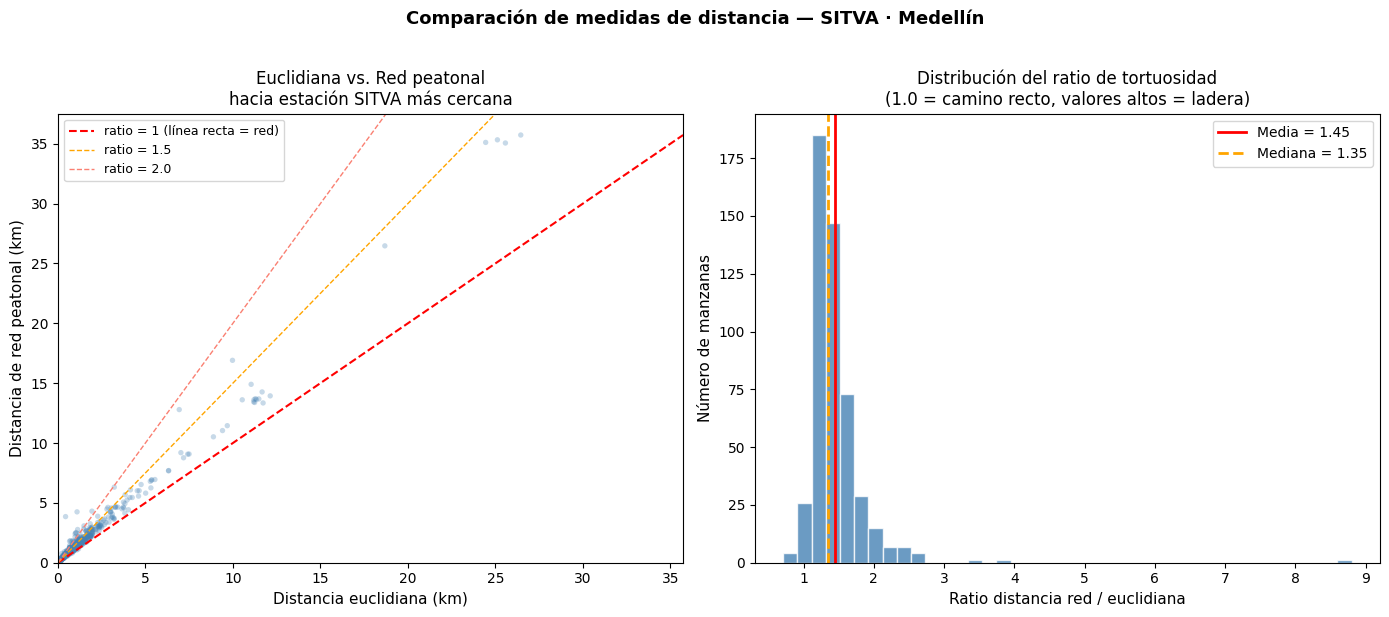

✓ Gráfico guardado: outputs/s02a_comparacion_distancias.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — Scatter plot: euclidiana vs. red + distribución del ratio
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: scatter euclidiana vs. red
ax = axes[0]
ax.scatter(
    resultado_df['dist_euclidiana_m'] / 1000,
    resultado_df['dist_red_m'] / 1000,
    alpha=0.3, s=15, color='steelblue', edgecolors='none'
)
# Línea identidad (ratio = 1)
lim = max(
    resultado_df['dist_euclidiana_m'].max(),
    resultado_df['dist_red_m'].max()
) / 1000
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='ratio = 1 (línea recta = red)')
ax.plot([0, lim], [0, lim*1.5], 'orange', lw=1, linestyle='--', label='ratio = 1.5')
ax.plot([0, lim], [0, lim*2.0], 'salmon', lw=1, linestyle='--', label='ratio = 2.0')
ax.set_xlabel('Distancia euclidiana (km)', fontsize=11)
ax.set_ylabel('Distancia de red peatonal (km)', fontsize=11)
ax.set_title('Euclidiana vs. Red peatonal\nhacia estación SITVA más cercana', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, lim)
ax.set_ylim(0, resultado_df['dist_red_m'].max()/1000 * 1.05)

# Panel derecho: distribución del ratio
ax2 = axes[1]
ax2.hist(
    resultado_df['ratio_red_euclidiana'].dropna(),
    bins=40, color='steelblue', edgecolor='white', alpha=0.8
)
ax2.axvline(
    resultado_df['ratio_red_euclidiana'].mean(),
    color='red', lw=2,
    label=f'Media = {resultado_df.ratio_red_euclidiana.mean():.2f}'
)
ax2.axvline(
    resultado_df['ratio_red_euclidiana'].median(),
    color='orange', lw=2, linestyle='--',
    label=f'Mediana = {resultado_df.ratio_red_euclidiana.median():.2f}'
)
ax2.set_xlabel('Ratio distancia red / euclidiana', fontsize=11)
ax2.set_ylabel('Número de manzanas', fontsize=11)
ax2.set_title('Distribución del ratio de tortuosidad\n(1.0 = camino recto, valores altos = ladera)', fontsize=12)
ax2.legend(fontsize=10)

plt.suptitle('Comparación de medidas de distancia — SITVA · Medellín', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

ruta_scatter = f'{RUTA_OUTPUTS}s02a_comparacion_distancias.png'
plt.savefig(ruta_scatter, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Gráfico guardado: {ruta_scatter}')

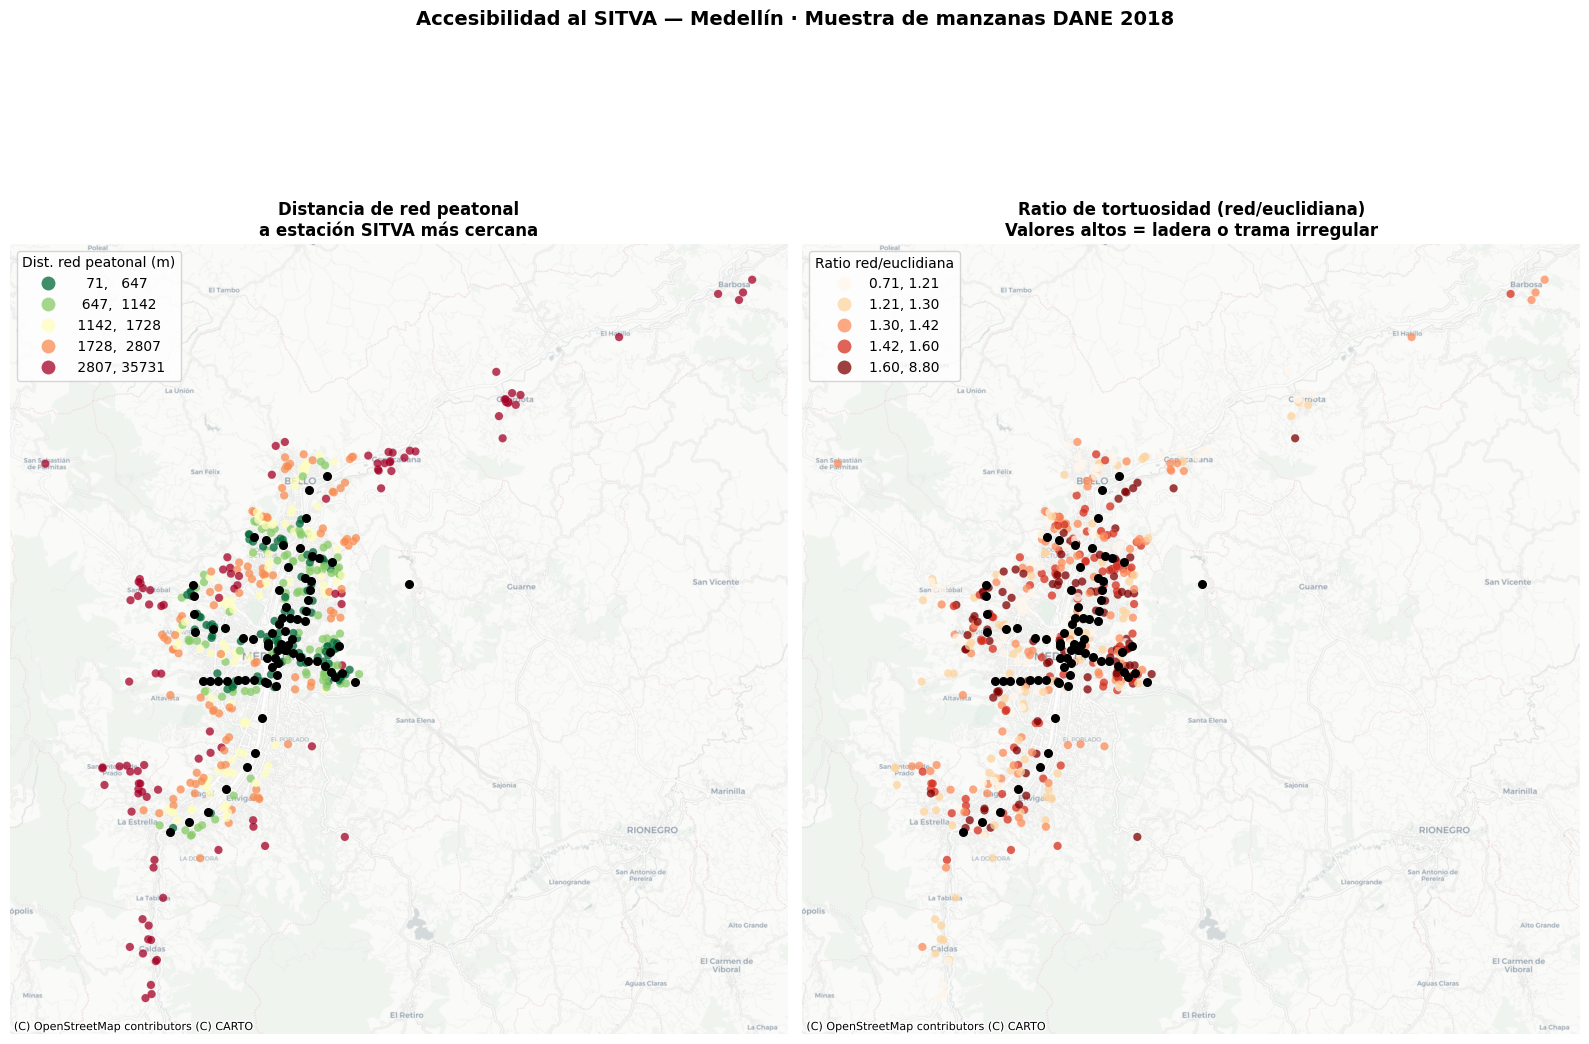

✓ Mapa guardado: outputs/s02a_mapa_red_ratio.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — Mapa del ratio de tortuosidad
# ─────────────────────────────────────────────────────────────────────────────
# El ratio revela dónde la topografía y la trama urbana penalizan más
# la accesibilidad real respecto a la euclidiana.

# Unir resultados a la muestra de manzanas
muestra_plot = muestra.copy().to_crs(epsg=3857)
muestra_plot = muestra_plot.merge(
    resultado_df[['dist_euclidiana_m','dist_red_m','ratio_red_euclidiana']],
    left_index=True, right_index=True, how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# Mapa izquierdo: distancia de red
muestra_plot.plot(
    column='dist_red_m',
    cmap='RdYlGn_r',
    scheme='quantiles', k=5,
    legend=True,
    legend_kwds={'title': 'Dist. red peatonal (m)', 'fmt': '{:.0f}'},
    alpha=0.75, linewidth=0.1, edgecolor='white',
    ax=axes[0], missing_kwds={'color':'lightgrey'}
)
sitva.to_crs(epsg=3857).plot(ax=axes[0], color='black', markersize=30, zorder=5)
try: ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron, zoom=12)
except: pass
axes[0].set_title('Distancia de red peatonal\na estación SITVA más cercana', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# Mapa derecho: ratio de tortuosidad
muestra_plot.plot(
    column='ratio_red_euclidiana',
    cmap='OrRd',
    scheme='quantiles', k=5,
    legend=True,
    legend_kwds={'title': 'Ratio red/euclidiana', 'fmt': '{:.2f}'},
    alpha=0.75, linewidth=0.1, edgecolor='white',
    ax=axes[1], missing_kwds={'color':'lightgrey'}
)
sitva.to_crs(epsg=3857).plot(ax=axes[1], color='black', markersize=30, zorder=5)
try: ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron, zoom=12)
except: pass
axes[1].set_title('Ratio de tortuosidad (red/euclidiana)\nValores altos = ladera o trama irregular', fontsize=12, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('Accesibilidad al SITVA — Medellín · Muestra de manzanas DANE 2018', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

ruta_mapa2 = f'{RUTA_OUTPUTS}s02a_mapa_red_ratio.png'
plt.savefig(ruta_mapa2, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Mapa guardado: {ruta_mapa2}')

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Exportar resultados
# ─────────────────────────────────────────────────────────────────────────────

# Exportar tabla de resultados
ruta_csv = f'{RUTA_OUTPUTS}s02a_distancias_sitva.csv'
resultado_df.to_csv(ruta_csv)

print('═' * 55)
print('  RESUMEN FINAL — s02a Distancias SITVA')
print('═' * 55)
print()
print(f'  Manzanas analizadas (muestra):   {len(resultado_df):,}')
print(f'  Estaciones SITVA:                {len(sitva)}')
print()
print('  ─── Distancia euclidiana ───')
print(f'  Media:    {resultado_df.dist_euclidiana_m.mean():,.0f} m')
print(f'  Mediana:  {resultado_df.dist_euclidiana_m.median():,.0f} m')
print(f'  ≤ 500m:   {(resultado_df.dist_euclidiana_m<=500).mean()*100:.1f}% de manzanas')
print()
print('  ─── Distancia de red peatonal ───')
print(f'  Media:    {resultado_df.dist_red_m.mean():,.0f} m')
print(f'  Mediana:  {resultado_df.dist_red_m.median():,.0f} m')
print(f'  ≤ 500m:   {(resultado_df.dist_red_m<=500).mean()*100:.1f}% de manzanas')
print()
print('  ─── Ratio de tortuosidad ───')
print(f'  Media:    {resultado_df.ratio_red_euclidiana.mean():.2f}x')
print(f'  Mediana:  {resultado_df.ratio_red_euclidiana.median():.2f}x')
print(f'  Máximo:   {resultado_df.ratio_red_euclidiana.max():.2f}x')
print()
print(f'  Archivos generados:')
print(f'  · {ruta_csv}')
print(f'  · {ruta_mapa}')
print(f'  · {ruta_scatter}')
print(f'  · {ruta_mapa2}')
print('═' * 55)

═══════════════════════════════════════════════════════
  RESUMEN FINAL — s02a Distancias SITVA
═══════════════════════════════════════════════════════

  Manzanas analizadas (muestra):   500
  Estaciones SITVA:                75

  ─── Distancia euclidiana ───
  Media:    1,813 m
  Mediana:  990 m
  ≤ 500m:   23.2% de manzanas

  ─── Distancia de red peatonal ───
  Media:    2,459 m
  Mediana:  1,431 m
  ≤ 500m:   14.2% de manzanas

  ─── Ratio de tortuosidad ───
  Media:    1.45x
  Mediana:  1.35x
  Máximo:   8.80x

  Archivos generados:
  · outputs/s02a_distancias_sitva.csv
  · outputs/s02a_distancia_euclidiana.png
  · outputs/s02a_comparacion_distancias.png
  · outputs/s02a_mapa_red_ratio.png
═══════════════════════════════════════════════════════


---
## Preguntas para la bitácora

1. ¿El ratio de tortuosidad varía espacialmente? ¿En qué zonas de Medellín es más alto? ¿Qué dice eso sobre la topografía y la trama urbana?

2. ¿Cuántas manzanas están a menos de 500m euclidiana de una estación pero a más de 500m de red? ¿Esas manzanas estarían dentro o fuera del área de influencia del SITVA si usas el criterio euclidiano?

3. Para tu variable dependiente del proyecto integrador: ¿usarías distancia euclidiana o distancia de red como variable independiente? ¿Por qué?

4. El ratio es siempre ≥ 1 por definición (la red nunca puede ser más corta que la línea recta). ¿Podría ser exactamente 1? ¿Cuándo?

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*